# Классификация токсичных комментариев - EDA-анализ и анализ данных

## Цели
1. Загрузить и изучить тренировочные/тестовые данные
2. Проанализировать распределение классов и дисбаланс
3. Понять характеристики текста (длина, языковое разнообразие)
4. Выявить проблемы с качеством данных
5. Подготовить данные для обучения модели

## Основные выводы
- Multi-label классификация: каждый комментарий может иметь несколько меток токсичности
- Дисбаланс классов: 'toxic' и 'identity_hate' встречаются очень редко
- Мультиязычный контент: содержит тексты на нескольких языках
- Различная длина комментариев: от нескольких токенов до сотен
- Отсутствуют пропущенные (null) значения в текстовых данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sys.path.insert(0, '../src')
from text_utils import clean_text, get_dataset_stats

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

DATA_DIR = Path('../data')
TRAIN_PATH = DATA_DIR / 'train.csv'
TEST_PATH = DATA_DIR / 'test.csv'

print("Настройка окружения завершена.")

Настройка окружения завершена.


## 1. Загрузка данных

In [4]:
df_train = pd.read_csv(TRAIN_PATH)
print("Тренировочные данные:")
print(f"  Размерность (Shape): {df_train.shape}")
print(f"  Колонки: {list(df_train.columns)}")
print(f"\nПервые 3 строки:")
print(df_train.head(3))

Тренировочные данные:
  Размерность (Shape): (159571, 8)
  Колонки: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Первые 3 строки:
                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  


In [5]:
df_test = pd.read_csv(TEST_PATH)
print("Тестовые данные:")
print(f"  Размерность (Shape): {df_test.shape}")
print(f"  Колонки: {list(df_test.columns)}")

Тестовые данные:
  Размерность (Shape): (153164, 2)
  Колонки: ['id', 'comment_text']


## 2. Проверка качества данных

In [7]:
print("Пропущенные значения в тренировочных данных:")
print(df_train.isnull().sum())
print(f"\nПустые записи: {(df_train['comment_text'] == '').sum()}")

Пропущенные значения в тренировочных данных:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

Пустые записи: 0


## 3. Анализ распределения классов

In [9]:
TOXICITY_LABELS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

y_train = df_train[TOXICITY_LABELS].values

print("Распределение классов (количество):")
class_counts = df_train[TOXICITY_LABELS].sum()
print(class_counts)

print("\nРаспределение классов (проценты):")
class_percentages = (df_train[TOXICITY_LABELS].sum() / len(df_train)) * 100
print(class_percentages)

print(f"\nКоэффициент дисбаланса классов: {class_counts.max() / class_counts.min():.2f}x")

Распределение классов (количество):
toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

Распределение классов (проценты):
toxic            9.584448
severe_toxic     0.999555
obscene          5.294822
threat           0.299553
insult           4.936361
identity_hate    0.880486
dtype: float64

Коэффициент дисбаланса классов: 32.00x


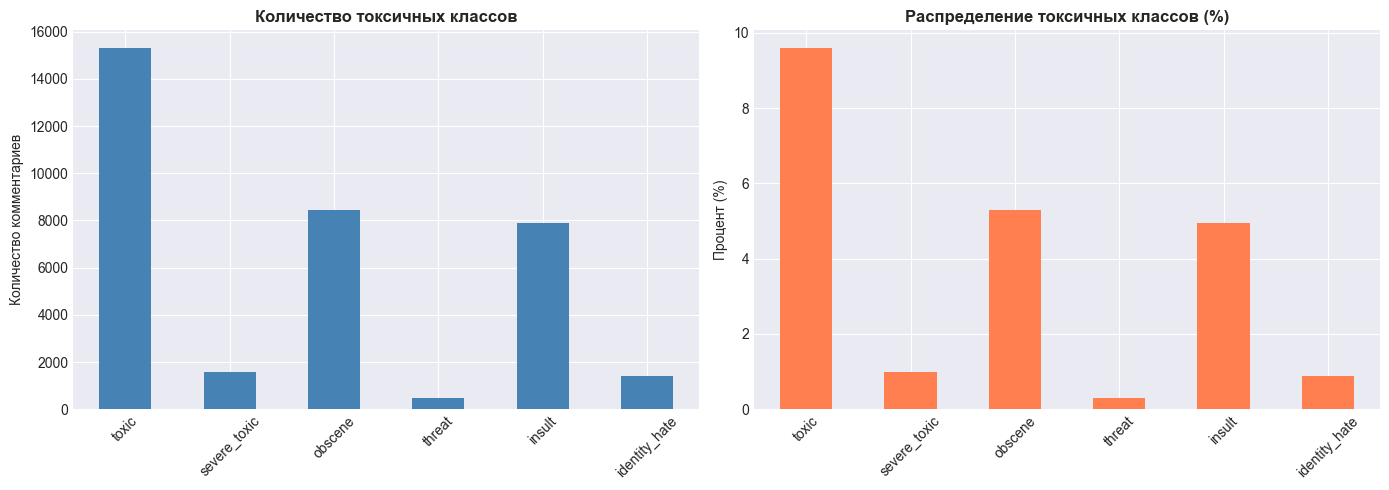

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Количество токсичных классов', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Количество комментариев')
axes[0].tick_params(axis='x', rotation=45)

class_percentages.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Распределение токсичных классов (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Процент (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Multi-Label анализ

In [12]:
num_labels_per_comment = df_train[TOXICITY_LABELS].sum(axis=1)

print("Распределение меток на комментарий:")
print(num_labels_per_comment.value_counts().sort_index())

print(f"\nЧистые комментарии (0 меток): {(num_labels_per_comment == 0).sum()}")
print(f"Токсичные комментарии (1+ меток): {(num_labels_per_comment > 0).sum()}")
print(f"Multi-label комментарии (2+ меток): {(num_labels_per_comment >= 2).sum()}")

Распределение меток на комментарий:
0    143346
1      6360
2      3480
3      4209
4      1760
5       385
6        31
Name: count, dtype: int64

Чистые комментарии (0 меток): 143346
Токсичные комментарии (1+ меток): 16225
Multi-label комментарии (2+ меток): 9865


## 5. Анализ текста

In [14]:
print("Статистика сырого текста:")
raw_stats = get_dataset_stats(df_train['comment_text'].tolist())
for key, value in raw_stats.items():
    print(f"  {key}: {value}")

Статистика сырого текста:
  num_samples: 159571
  avg_length: 67.27352714465661
  min_length: 1
  max_length: 1411
  median_length: 36.0
  std_length: 99.23039126279367


In [15]:
print("Очистка текстов...")
df_train['comment_text_cleaned'] = df_train['comment_text'].apply(clean_text)

print("Статистика очищенного текста:")
cleaned_stats = get_dataset_stats(df_train['comment_text_cleaned'].tolist())
for key, value in cleaned_stats.items():
    print(f"  {key}: {value}")

Очистка текстов...
Статистика очищенного текста:
  num_samples: 159571
  avg_length: 67.27352714465661
  min_length: 1
  max_length: 1411
  median_length: 36.0
  std_length: 99.23039126279367


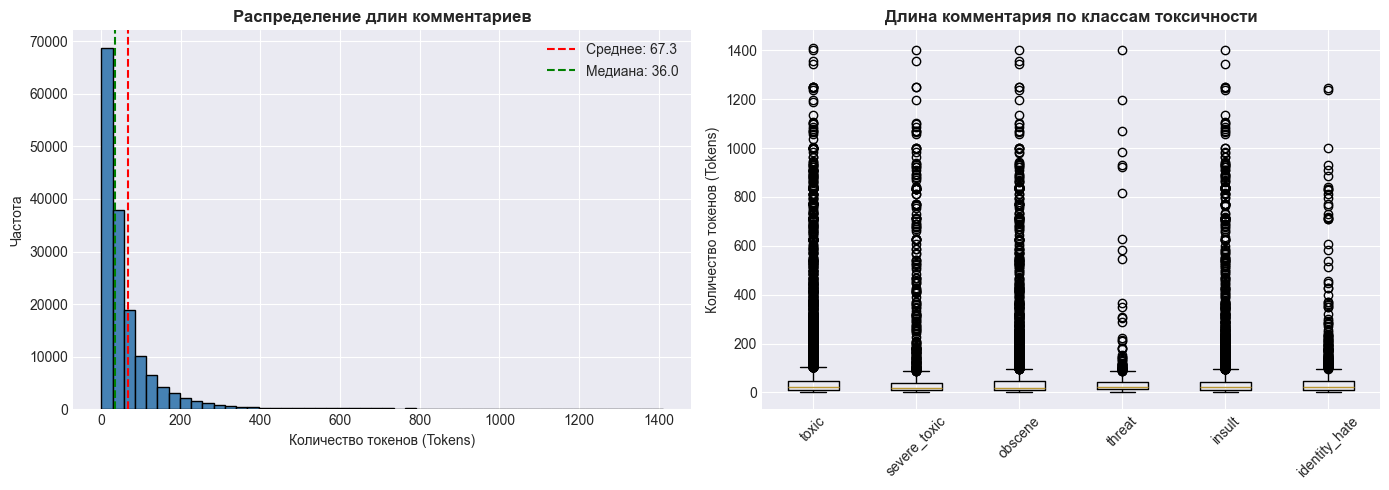

In [16]:
text_lengths = df_train['comment_text_cleaned'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(text_lengths, bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Распределение длин комментариев', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Количество токенов (Tokens)')
axes[0].set_ylabel('Частота')
axes[0].axvline(text_lengths.mean(), color='red', linestyle='--', label=f'Среднее: {text_lengths.mean():.1f}')
axes[0].axvline(text_lengths.median(), color='green', linestyle='--', label=f'Медиана: {text_lengths.median():.1f}')
axes[0].legend()

length_data = [text_lengths[df_train[label] == 1] for label in TOXICITY_LABELS]

axes[1].boxplot(length_data, tick_labels=TOXICITY_LABELS)

axes[1].set_title('Длина комментария по классам токсичности', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Количество токенов (Tokens)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Примеры комментариев

In [18]:
clean_comments = df_train[df_train[TOXICITY_LABELS].sum(axis=1) == 0].sample(3, random_state=42)
print("Примеры ЧИСТЫХ комментариев:")
print("="*80)
for idx, row in clean_comments.iterrows():
    print(f"Текст: {row['comment_text'][:200]}")
    print("-" * 80)

Примеры ЧИСТЫХ комментариев:
Текст: "

Oh, don't worry about me, Sandstein. I'm of no strong opinion as to what is ""well."" Editing Wikipedia is not a personal benefit; if it were, I'd be COI! I do have some unfinished business, both w
--------------------------------------------------------------------------------
Текст: Are you trying to dispute that fact?
--------------------------------------------------------------------------------
Текст: SWOT analysis 

This source – Align Technology, Inc. SWOT Analysis. (2013). 1-8. – is used 11 times, with no indication of how to find it or whether it's a primary source (I assume it is), so I'm goin
--------------------------------------------------------------------------------


In [19]:
toxic_comments = df_train[df_train['toxic'] == 1].sample(3, random_state=42)
print("Примеры ТОКСИЧНЫХ комментариев:")
print("="*80)
for idx, row in toxic_comments.iterrows():
    labels = [label for label in TOXICITY_LABELS if row[label] == 1]
    print(f"Метки: {labels}")
    print(f"Текст: {row['comment_text'][:200]}")
    print("-" * 80)

Примеры ТОКСИЧНЫХ комментариев:
Метки: ['toxic', 'obscene']
Текст: Hi! 

I wanna rape you!
--------------------------------------------------------------------------------
Метки: ['toxic', 'obscene', 'threat', 'insult']
Текст: Terrorize 
I will terrorise you for as long as you live - you are an arrogant, disgusting and rude excuse for a human being & you are going to die soon so I suggest you stop threatening people you bas
--------------------------------------------------------------------------------
Метки: ['toxic']
Текст: Being blocked

So that's your idea of mediation, is it? R Lopez can run amok through Wikipedia with his lying crap, and I get blocked for stating my intention of stopping him unless Wikipedia's rather
--------------------------------------------------------------------------------


## 7. Итоги

### Основные выводы
1. **Сильный дисбаланс классов** - ~90% чистых, ~10% токсичных
2. **Multi-label** - комментарии могут иметь несколько типов токсичности
3. **Мультиязычность** - сохраняется неанглоязычный текст
4. **Различная длина** - от 1 до 5000+ токенов (tokens)

### Подход
- Использование метрики ROC AUC (хорошо справляется с дисбалансом)
- Сохранение всех языков при предобработке
- Использование max_length=150 для последовательностей
- Применение стратифицированного разбиения (stratified split) для сохранения распределений